# Day 12 — FlowingData Theme Day
### #30DayChartChallenge | April 2026

**The E-Waste Recycling Gap.** Following Day 11's circle-packing of total e-waste, this chart answers: how much actually gets recycled? For the top 25 producing countries, each bar shows total e-waste generated (red = uncollected, green = formally collected). Country flags replace text labels. Sorted by total generated.

**Data:** Global E-waste Monitor 2024 (UNITAR/ITU) via [globalewaste.org](https://globalewaste.org/map/)  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(tidyr)
library(showtext)
library(sysfonts)
library(ggimage)
library(countrycode)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: sysfonts

Loading required package: showtextdb

Warning message:
"package 'ggimage' was built under R version 4.5.3"
Warning message:
"package 'countrycode' was built under R version 4.5.3"


In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 14, repr.plot.height = 12, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------
# Source: GEM 2024 (UNITAR/ITU) via globalewaste.org/map/

df <- read.csv("../../data/day_12/ewaste_recycling_gap.csv",
               stringsAsFactors = FALSE)

# Flags
df$iso2 <- tolower(countrycode(df$country, "country.name", "iso2c",
  custom_match = c("Taiwan" = "tw", "Hong Kong" = "hk")))
df$flag_url <- paste0("https://flagcdn.com/w80/", df$iso2, ".png")

# Sort by total generated (biggest at top)
df$country <- factor(df$country, levels = rev(df$country[order(df$generated_mt)]))

# Pivot for stacked bar
df_long <- df %>%
  select(country, continent, collection_rate, flag_url,
         Collected = collected_mt, Uncollected = uncollected_mt) %>%
  pivot_longer(cols = c(Collected, Uncollected),
               names_to = "status", values_to = "amount_mt")

df_long$status <- factor(df_long$status, levels = c("Uncollected", "Collected"))

head(df)

,country,continent,generated_mt,collected_mt,uncollected_mt,collection_rate,iso2,flag_url
,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
1,China,Asia,12.07,1.95,10.12,16,cn,https://flagcdn.com/w80/cn.png
2,United States,Americas,7.19,4.05,3.14,56,us,https://flagcdn.com/w80/us.png
3,India,Asia,4.14,0.06,4.08,1,in,https://flagcdn.com/w80/in.png
4,Japan,Asia,2.64,0.61,2.03,23,jp,https://flagcdn.com/w80/jp.png
5,Brazil,Americas,2.44,0.08,2.36,3,br,https://flagcdn.com/w80/br.png
6,Russia,Europe,1.91,0.12,1.79,6,ru,https://flagcdn.com/w80/ru.png


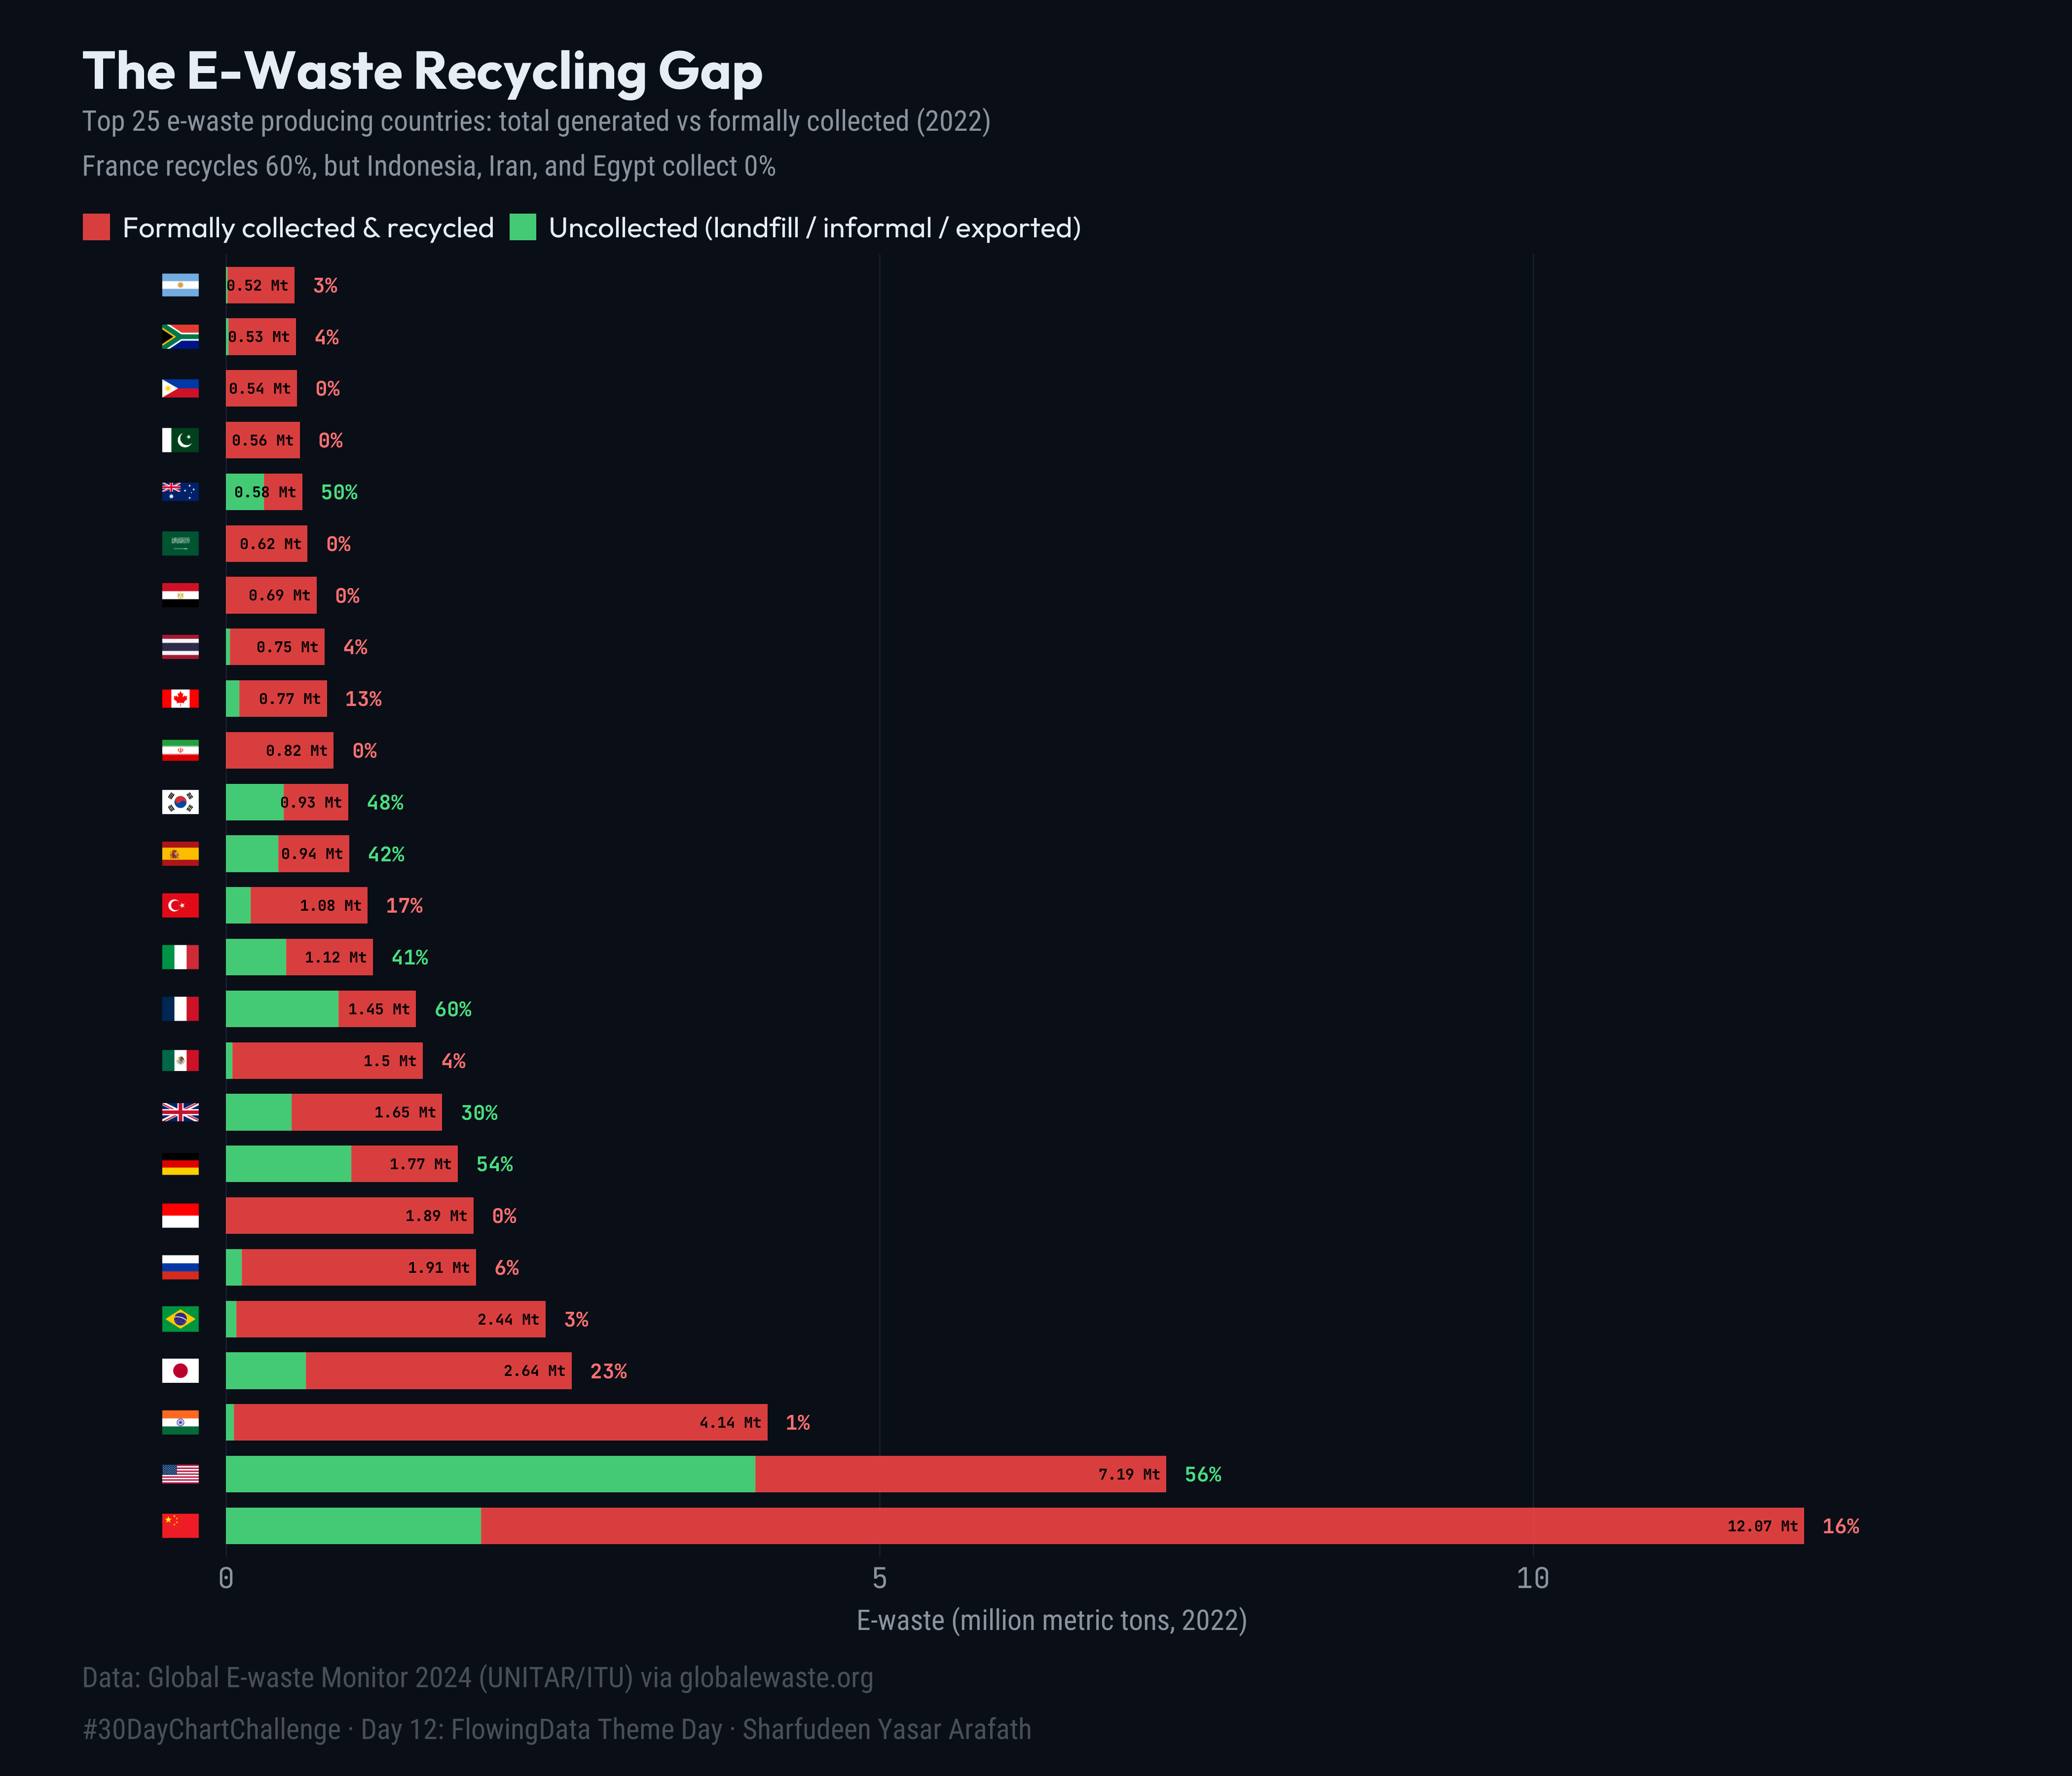

In [4]:
# — build the plot ------------------------------------------------------------

bg <- "#0a0e17"; txt <- "#E6EDF3"; txt_dim <- "#8B949E"
txt_cap <- "#484F58"; grid_col <- "#1a2030"

rate_colors <- ifelse(df$collection_rate >= 30, "#4ade80", "#f87171")

p <- ggplot(df_long, aes(x = amount_mt, y = country, fill = status)) +
  geom_col(width = 0.7, alpha = 0.9) +

  # Flags as y-axis labels
  geom_image(data = df,
    aes(x = -0.35, y = country, image = flag_url, fill = NULL),
    size = 0.028, inherit.aes = FALSE) +

  # Rate % at end of bar
  geom_text(data = df,
    aes(x = generated_mt + 0.15, y = country,
        label = paste0(collection_rate, "%"), fill = NULL),
    family = "jetbrains", fontface = "bold", size = 3.5,
    color = rate_colors, hjust = 0) +

  # Total Mt inside bar (size 10, black)
  geom_text(data = df,
    aes(x = generated_mt - 0.05, y = country,
        label = paste0(generated_mt, " Mt"), fill = NULL),
    family = "jetbrains", fontface = "bold", size = 2.5,
    color = "#000000", hjust = 1) +

  scale_fill_manual(
    values = c("Collected" = "#4ade80", "Uncollected" = "#ef4444"),
    labels = c("Formally collected & recycled",
               "Uncollected (landfill / informal / exported)")
  ) +
  scale_x_continuous(expand = expansion(mult = c(0.06, 0.12))) +

  labs(
    title = "The E-Waste Recycling Gap",
    subtitle = paste0(
      "Top 25 e-waste producing countries: total generated vs formally collected (2022)\n",
      "France recycles 60%, but Indonesia, Iran, and Egypt collect 0%"
    ),
    x = "E-waste (million metric tons, 2022)",
    y = NULL, fill = NULL,
    caption = paste0(
      "Data: Global E-waste Monitor 2024 (UNITAR/ITU) via globalewaste.org\n",
      "#30DayChartChallenge \u00b7 Day 12: FlowingData Theme Day \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  coord_cartesian(clip = "off") +

  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 26,
      color = txt, margin = margin(t = 10, b = 5)),
    plot.subtitle = element_text(size = 14, color = txt_dim,
      lineheight = 1.3, margin = margin(b = 15)),
    plot.caption = element_text(size = 14, hjust = 0, color = txt_cap,
      lineheight = 1.5, margin = margin(t = 15)),

    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x = element_text(size = 14, color = txt_dim, family = "jetbrains"),
    axis.title.x = element_text(size = 14, color = txt_dim, margin = margin(t = 8)),

    legend.position = "top",
    legend.justification = "left",
    legend.text = element_text(size = 14, color = txt, family = "outfit"),
    legend.key.size = unit(0.5, "cm"),
    legend.margin = margin(b = -5),

    panel.grid.major.x = element_line(color = grid_col, linewidth = 0.2),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(15, 25, 15, 40)
  )

p

In [ ]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_12_flowingdata.png",
       plot = p, width = 14, height = 12, dpi = 300, bg = bg)

cat("Done \u2014 saved to chart/day_12_flowingdata.png\n")

Done — saved to chart/day_12_flowingdata.png


: 